# Exercise 1: Digit Classification with Logistic Regression

In this notebook we will use simple logistic regression to see how far we can get when classifying images with digits on it. For this we use the famous MNIST dataset.

### 1. Data Loading and Analysis

We work with the MNIST dataset which is a large database of handwritten digits and very popular for testing machine learning models. You can find more details about the dataset [here](https://en.wikipedia.org/wiki/MNIST_database).

We download the dataset directly via the sklearn library. This may take a short while ... 

In [2]:
from sklearn.datasets import fetch_openml
x, y = fetch_openml('mnist_784', version=1, return_X_y=True, data_home="./data")

Next, we have a brief look at the data:

In [3]:
print("X is a", type(x))
print("y is a", type(y))

X is a <class 'pandas.DataFrame'>
y is a <class 'pandas.Series'>


In [4]:
x.shape

(70000, 784)

In [5]:
x.head(3)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


One data point consists of 784 pixel values (=28x28 pixels) that represent an image showing a handwritten digit.
Let's look at the data for one data point:

In [6]:
x.iloc[0].describe()

count    784.000000
mean      35.108418
std       79.699674
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      255.000000
Name: 0, dtype: float64

The pixels of one datapoint have values between 0 and 255 which correspond to the grey value of that pixel. A value of zero means that the pixel is black, a value of 255 corresponds to a white pixel, every other value is some grey value in between.

The labels of the data are the digits that are actually shown on the image:

In [7]:
y.head(3)

0    5
1    0
2    4
Name: class, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [8]:
type(y.iloc[0])

str

Since the label is of type string, we convert it to an integer:

In [9]:
y = y.astype("int")

To get an impression how the pictures of the digits look like, we visualize the first three rows with matplotlib. For this, we need to reshape each row to dimension 28x28 and then plot it.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

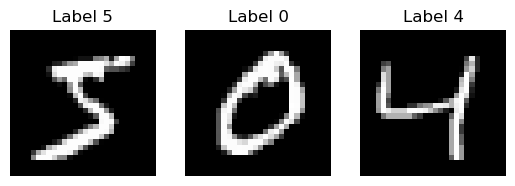

In [10]:
import numpy as np
import matplotlib.pyplot as plt

digit = x.iloc[0]
digit_pixels = np.array(digit).reshape(28, 28)
plt.subplot(131)
plt.title("Label " + str(y.iloc[0]))
plt.imshow(digit_pixels, cmap=plt.cm.gray)
plt.axis('off')

digit = x.iloc[1]
digit_pixels = np.array(digit).reshape(28, 28)
plt.subplot(132)
plt.title("Label " + str(y.iloc[1]))
plt.imshow(digit_pixels, cmap=plt.cm.gray)
plt.axis('off')

digit = x.iloc[2]
digit_pixels = np.array(digit).reshape(28, 28)
plt.subplot(133)
plt.title("Label " + str(y.iloc[2]))
plt.imshow(digit_pixels, cmap=plt.cm.gray)
plt.axis('off')

Before we start with the model training we divide it into train and test data.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("Train data points:", len(X_train))
print("Test data points:", len(X_test))

Train data points: 56000
Test data points: 14000


### 2. Model Training

Your exercise is now to train a logistic regression model using an one-vs-rest approach (see lecture slides).

For this, implement the following steps:
1. Apply min-max normalization to `X_train` and `X_test` to normalize the data.
2. Train a binary logistic regression to predict: "Is there the digit `9` on the image ?". Hint: For this you need to change the labels in `y_train`. Calculate the accuaracy of this classifer on the test data (you need to change also the labels in `y_test`).
3. Train a binary logistic regression on each digit from `0` to `9`. Save each model in a list.
4. For every test data point, predict which each model on it to find out which models returns the highest probability for the point. Hint: Use `.predict_proba()` to get class probabilities from each binary classifier.
5. Use the results from step 4 to calculate the accuracy of the overall approach on the test data. A correct implementation should achieve approximately 90% accuracy on test data.
7. Use `GridSearchCV` to tune the regularization parameter `C` (try values like 0.1, 1.0, 10.0) with 5-fold cross-validation.

# 1. Aufgabe
## Formel
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} = \frac{0 - 0}{0 - 0} = ?$$

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
# 1
X_train.shape

(56000, 784)

In [14]:
print(X_train.max(axis=0).min(), X_train.max(axis=0).max())
print((X_train.max(axis=0) == 0).sum())

0 255
70


In [15]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [16]:
X_train_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(56000, 784))

In [17]:
X_test_scaled = scaler.transform(X_test)

# 2. Aufgabe
"Is there a digit 9 on the image?"

In [18]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [19]:
# True und False Spalte schaffen
y_train_9 = (y_train == 9).astype(int)
y_test_9 = (y_test == 9).astype(int)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train_9)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
y_pred = model.predict(X_test_scaled)

In [23]:
accuracy_score(y_test_9, y_pred)

0.9653571428571428

In [24]:
y_test_9.mean()

np.float64(0.09721428571428571)

In [25]:
from sklearn.metrics import classification_report
target_names = ['has no 9', 'has 9']
print(classification_report(y_test_9, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    has no 9       0.98      0.98      0.98     12639
       has 9       0.85      0.78      0.81      1361

    accuracy                           0.97     14000
   macro avg       0.91      0.88      0.90     14000
weighted avg       0.96      0.97      0.96     14000



# 3. Aufgabe
train logreg on each digit from 0 to 9, model saved to list (aka alles aus Schritt 2 wiederholen für alle digits)

In [26]:
models = []

In [27]:
for r in range (0, 10):
    y_train_x = (y_train == r).astype(int)
    y_test_x = (y_test == r).astype(int)

    model = LogisticRegression(random_state=42)
    model.fit(X_train_scaled, y_train_x)
    models.append(model)

# 4. Aufgabe
For every test data point, predict which each model on it to find out which models returns the highest probability for the point. Hint: Use `.predict_proba()` to get class probabilities from each binary classifier.


In [28]:
models[0].predict_proba(X_test_scaled)

array([[2.67496569e-03, 9.97325034e-01],
       [9.99489089e-01, 5.10910567e-04],
       [9.99999998e-01, 1.60227169e-09],
       ...,
       [9.99850655e-01, 1.49345169e-04],
       [9.99989608e-01, 1.03917530e-05],
       [9.99999372e-01, 6.27796524e-07]], shape=(14000, 2))

In [29]:
proba_list = []

In [30]:
for r in range(0, 10):
    proba_r = models[r].predict_proba(X_test_scaled)[:, 1]
    proba_list.append(proba_r)

proba_matrix = np.column_stack(proba_list)


In [31]:
proba_matrix.shape

(14000, 10)

In [32]:
max_vals = np.argmax(proba_matrix, axis=1) # axis 0=spalten, axis 1=zeilen
max_vals.shape

(14000,)

$$\text{proba\_matrix}[5,\ \text{max\_vals}[5]] = \max(\text{proba\_matrix}[5, :])$$

In [33]:
# proba_matrix[5, :]                # alle Werte für Bild 5 (Zeile 5)
print(proba_matrix[5, :].max())     # der höchste Wert
max_vals[5]                         # 4 -> der Index, an dem der höchste Wert steht

0.06481442547990128


np.int64(4)

# 5. Aufgabe
Use the results from step 4 to calculate the accuracy of the overall approach on the test data. A correct implementation should achieve approximately 90% accuracy on test data.


In [34]:
accuracy = accuracy_score(y_test, max_vals)
print(accuracy)

0.9112857142857143


# 6. Aufgabe
Use `GridSearchCV` to tune the regularization parameter `C` (try values like 0.1, 1.0, 10.0) with 5-fold cross-validation.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1.0, 10.0]}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=100),
    param_grid=param_grid,
    cv=5
)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

/opt/anaconda3/envs/dscb130-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/dscb130-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

In [37]:
print(grid_search.best_params_)
print(f"Bester Score: {grid_search.best_score_}")

{'C': 0.1}
Bester Score: 0.9224821428571428


In [38]:
model_untuned = LogisticRegression(random_state=42, max_iter=1000)
model_untuned.fit(X_train_scaled, y_train)

y_pred_untuned = model_untuned.predict(X_test_scaled)

In [39]:
y_pred_1 = best_model.predict(X_test_scaled)

print(f"{accuracy_score(y_test, y_pred_1)} GridSearchCV Accuracy vs. {accuracy_score(y_test, y_pred_untuned)} Untuned")

0.9188571428571428 GridSearchCV Accuracy vs. 0.9175 Untuned
